In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except:
    ! pip install seaborn
    import seaborn as sns
from tqdm import tqdm

## Helper Classes

In [2]:
class ExploratoryDataAnalysis:
    def __init__(self, str_uri, str_target, str_dirname_output):
        self.str_uri = str_uri
        self.str_target = str_target
        self.str_dirname_output = str_dirname_output

    def import_data(self):
        df = pd.read_csv(self.str_uri)
        for col in tqdm(['origination_date', 'dob']):
            df[col] = pd.to_datetime(df[col], errors='coerce')
        df.sort_values(by='origination_date', ascending=True, inplace=True)
        df['term_months'] = df['term_months'].replace(0, np.nan)
        df['channel'] = df['channel'].str.lower().str.strip()
        df['state'] = df['state'].str.lower().str.strip()
        self.df = df

    def get_df_info(self):
        int_nrows, int_ncols = self.df.shape
        dtm_min = self.df['origination_date'].min()
        dtm_max = self.df['origination_date'].max()
        flt_nan = self.df.isna().values.mean()
        flt_default_rate = self.df[self.str_target].mean()
        print(f'Rows: {int_nrows}')
        print(f'Columns: {int_ncols}')
        print(f'Min Date: {dtm_min}')
        print(f'Max Date: {dtm_max}')
        print(f'Proportion NaN: {flt_nan:0.4f}')
        print(f'Default Rate: {flt_default_rate:0.4f}')
        self.int_nrows = int_nrows
        self.int_ncols = int_ncols

    def fe_for_eda(self):
        df_tmp = self.df.copy()
        df_tmp['age'] = (pd.Timestamp.today() - df_tmp['dob']).dt.days // 365
        df_dummies = pd.get_dummies(df_tmp[['channel', 'state']], columns=['channel', 'state'], dtype=int)
        df = pd.concat([df_tmp, df_dummies], axis=1)
        df['origination_month'] = df['origination_date'].dt.to_period('M').dt.to_timestamp()
        self.df = df

    def descriptives(self):
        list_cols_no = ['loan_id', 'origination_date', 'dob', 'origination_month', 'channel', 'state']
        list_cols = [col for col in self.df.columns if col not in list_cols_no]
        list_dict_row = []
        for col in tqdm(list_cols):
            dict_row = {
                'col': col,
                'nan': self.df[col].isnull().mean(),
                'nunique': self.df[col].nunique(),
                'min': self.df[col].min(),
                'max': self.df[col].max(),
                'mean': self.df[col].mean(),
                'std': self.df[col].std(),
                'mdn': self.df[col].median(),
            }
            list_dict_row.append(dict_row)
        self.df_descriptives = pd.DataFrame(list_dict_row)

    def plot_target_by_month(self):
        df_tmp = self.df.copy()
        df_tmp['count'] = 1
        df_pivot = df_tmp.groupby(by='origination_month', as_index=False).agg({
            self.str_target: 'mean', 'count': 'sum',
        })
        x = df_pivot['origination_month']
        y = df_pivot[self.str_target]
        y2 = df_pivot['count']
        int_n_months = len(x)
        int_n_total = y2.sum()
        flt_n_per_month = int_n_total / int_n_months

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.set_title(f'Default Rate and Origination Volume by Month (N={int_n_total:,}; {int_n_months} months; ~{flt_n_per_month:,.0f}/month)')
        ax.set_xlabel('Origination Month')
        ax.set_ylabel('Default Rate', color='tab:blue')
        ax.plot(x, y, color='tab:blue', marker='o', markersize=4, label='Default Rate')
        ax.tick_params(axis='y', labelcolor='tab:blue')
        ax2 = ax.twinx()
        ax2.bar(x, y2, alpha=0.3, color='tab:red', width=20, label='N Funded')
        ax2.set_ylabel('N Funded', color='tab:red')
        ax2.tick_params(axis='y', labelcolor='tab:red')
        fig.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/target_by_month.png', bbox_inches='tight', dpi=150)
        plt.show()

    def correlation_with_target(self):
        list_cols_no = ['loan_id', 'origination_date', 'dob', self.str_target,
                        'charged_off_amount', 'paid_interest_amount', 'origination_month', 'channel', 'state']
        list_cols = [col for col in self.df.columns if col not in list_cols_no]
        dv = self.df[self.str_target]
        list_dict_row = []
        for col in list_cols:
            iv = self.df[col]
            df_tmp = pd.DataFrame({'dv': dv, 'iv': iv}).dropna(subset=['iv'])
            int_n_unique = df_tmp['iv'].nunique()
            if int_n_unique <= 1:
                continue
            flt_correlation = df_tmp['iv'].corr(df_tmp['dv'])
            str_type = 'phi' if int_n_unique == 2 else 'point_biserial'
            list_dict_row.append({'col': col, 'type': str_type, 'correlation': flt_correlation})
        df_corr = pd.DataFrame(list_dict_row)
        df_corr['correlation_abs'] = df_corr['correlation'].abs()
        df_corr.sort_values(by='correlation_abs', ascending=True, inplace=True)
        self.df_corr = df_corr

    def plot_correlation_with_target(self):
        # filter to top features (exclude state dummies for readability)
        df_plot = self.df_corr[~self.df_corr['col'].str.startswith('state_')].copy()
        df_plot.sort_values(by='correlation_abs', ascending=True, inplace=True)
        colors = ['tab:red' if c > 0 else 'tab:blue' for c in df_plot['correlation']]
        fig, ax = plt.subplots(figsize=(9, 8))
        ax.set_title(f'Correlation with {self.str_target} (Signed)')
        ax.set_xlabel('Correlation')
        ax.barh(df_plot['col'], df_plot['correlation'], color=colors)
        ax.axvline(x=0, color='black', linewidth=0.5)
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/correlation_with_target.png', bbox_inches='tight', dpi=150)
        plt.show()

    def plot_correlation_heatmap(self):
        list_cols_numeric = [
            'loan_amount', 'term_months', 'employment_length_years', 'stated_income',
            'has_prior_loans_with_us', 'bureau_score', 'open_trades', 'delinq_12m',
            'utilization', 'inquiries_6m', 'public_records', 'age', self.str_target,
        ]
        df_corr_matrix = self.df[list_cols_numeric].corr()
        mask = np.triu(np.ones_like(df_corr_matrix, dtype=bool))
        fig, ax = plt.subplots(figsize=(12, 10))
        ax.set_title('Feature Correlation Heatmap')
        sns.heatmap(df_corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                    center=0, vmin=-1, vmax=1, square=True, ax=ax,
                    linewidths=0.5, cbar_kws={'shrink': 0.8})
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/correlation_heatmap.png', bbox_inches='tight', dpi=150)
        plt.show()

    def make_violin_plots(self):
        list_cols = [
            'loan_amount', 'stated_income', 'bureau_score', 'employment_length_years',
            'open_trades', 'utilization', 'inquiries_6m', 'age',
        ]
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        fig.suptitle('Feature Distributions (Violin Plots)', fontsize=16, y=1.02)
        for idx, col in enumerate(list_cols):
            row, col_idx = divmod(idx, 4)
            ax = axes[row][col_idx]
            sns.violinplot(data=self.df, y=col, ax=ax, color='tab:blue', alpha=0.7)
            ax.set_title(col)
            ax.set_ylabel('')
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/violin_plots.png', bbox_inches='tight', dpi=150)
        plt.show()

    def _make_lift_subplot(self, df, col, ax):
        str_target = self.str_target
        int_q = 10
        while int_q >= 2:
            try:
                df['_tmp'] = pd.qcut(df[col], q=int_q, labels=False)
                break
            except ValueError:
                int_q -= 1
        if int_q < 2:
            df['_tmp'] = df[col]
        df_pivot = df.groupby(by='_tmp', as_index=False).agg({str_target: 'mean'})
        df_pivot.sort_values(by='_tmp', ascending=True, inplace=True)
        ax.plot(df_pivot['_tmp'], df_pivot[str_target], marker='o', markersize=4)
        ax.set_title(col)
        ax.set_xlabel('Quantile')
        ax.set_ylabel('Default Rate')
        ax.set_xticks(df_pivot['_tmp'].values)
        df.drop('_tmp', axis=1, inplace=True)

    def make_lift_plots(self):
        df = self.df.copy()

        # Grid 1: Core continuous features (2x3)
        list_cols_1 = ['bureau_score', 'stated_income', 'loan_amount',
                       'utilization', 'employment_length_years', 'term_months']
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle('Lift Plots: Continuous Features', fontsize=16, y=1.02)
        for idx, col in enumerate(list_cols_1):
            row, col_idx = divmod(idx, 3)
            self._make_lift_subplot(df, col, axes[row][col_idx])
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/lift_plots_continuous.png', bbox_inches='tight', dpi=150)
        plt.show()

        # Grid 2: Count/discrete + binary features (2x3)
        list_cols_2 = ['open_trades', 'delinq_12m', 'inquiries_6m',
                       'public_records', 'has_prior_loans_with_us', 'age']
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle('Lift Plots: Discrete and Binary Features', fontsize=16, y=1.02)
        for idx, col in enumerate(list_cols_2):
            row, col_idx = divmod(idx, 3)
            self._make_lift_subplot(df, col, axes[row][col_idx])
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/lift_plots_discrete.png', bbox_inches='tight', dpi=150)
        plt.show()

        # Grid 3: Channel features (1x3)
        list_cols_3 = ['channel_mobile', 'channel_partner', 'channel_web']
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle('Lift Plots: Channel Features', fontsize=16, y=1.05)
        for idx, col in enumerate(list_cols_3):
            self._make_lift_subplot(df, col, axes[idx])
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/lift_plots_channel.png', bbox_inches='tight', dpi=150)
        plt.show()

## Constants

In [3]:
str_bucket = 'credit-risk-model-demo'
print(f'Bucket: {str_bucket}')

str_task = '01_eda'
print(f'Task: {str_task}')

str_dirname_output = './output'

str_target = 'default_12m'

# data uri
str_filename = 'data.csv'
str_uri = f's3://{str_bucket}/00_data_collection/{str_filename}'

Bucket: credit-risk-model-demo
Task: 01_eda


## Output Directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

## Initialize EDA Class

In [5]:
cls_eda = ExploratoryDataAnalysis(
    str_uri=str_uri,
    str_target=str_target,
    str_dirname_output=str_dirname_output,
)

## Import Data

In [6]:
cls_eda.import_data()
cls_eda.df

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)
100%|██████████| 2/2 [00:00<00:00, 17.77it/s]


,loan_id,origination_date,dob,loan_amount,term_months,channel,employment_length_years,stated_income,state,has_prior_loans_with_us,bureau_score,open_trades,delinq_12m,utilization,inquiries_6m,public_records,default_12m,charged_off_amount,paid_interest_amount,apr
5891,17794,2022-01-01,1992-02-29,5410,18.0,partner,8.39,2951.0,wi,0,604.0,1.0,1.0,0.47,3.0,1,0,0.00,1715.89,0.221
13404,13499,2022-01-01,1966-05-05,10000,12.0,web,4.52,5410.0,fl,0,600.0,2.0,0.0,0.46,3.0,0,0,0.00,1672.59,0.209
11238,24476,2022-01-01,1985-02-06,8480,12.0,web,3.81,3244.0,tx,0,557.0,2.0,0.0,0.48,5.0,2,0,0.00,2379.19,0.303
5589,5438,2022-01-01,1981-11-06,3510,18.0,web,9.82,5147.0,il,1,651.0,3.0,0.0,0.18,1.0,0,0,0.00,706.84,0.150
1244,11493,2022-01-01,1991-11-27,6630,24.0,web,4.99,6389.0,tx,1,611.0,1.0,0.0,0.41,3.0,1,0,0.00,2160.10,0.159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15382,23591,2024-12-28,1975-12-12,6970,12.0,mobile,9.41,6511.0,wa,0,607.0,2.0,1.0,0.47,4.0,1,0,0.00,1147.42,0.200
9616,15828,2024-12-28,1984-11-26,8450,12.0,mobile,8.97,4278.0,tn,1,662.0,6.0,0.0,0.52,2.0,0,0,0.00,1163.61,0.160
7158,17304,2024-12-28,2003-07-07,970,24.0,web,4.01,3885.0,mo,0,595.0,2.0,0.0,0.34,0.0,0,0,0.00,287.05,0.166
22683,13374,2024-12-28,1975-12-01,5700,12.0,mobile,7.10,13121.0,ga,0,583.0,2.0,0.0,0.31,2.0,2,0,0.00,803.60,0.156


## Dataset Summary

In [7]:
cls_eda.get_df_info()

Rows: 25308
Columns: 20
Min Date: 2022-01-01 00:00:00
Max Date: 2024-12-28 00:00:00
Proportion NaN: 0.0066
Default Rate: 0.1868


## Feature Engineering for EDA

In [8]:
cls_eda.fe_for_eda()

## Descriptive Statistics

In [9]:
cls_eda.descriptives()
cls_eda.df_descriptives

100%|██████████| 42/42 [00:00<00:00, 699.16it/s]


,col,nan,nunique,min,max,mean,std,mdn
0,loan_amount,0.000000,1037,700.00,49930.000,5465.570966,3124.847601,4890.000
1,term_months,0.003003,6,6.00,84.000,19.083386,9.602377,18.000
2,employment_length_years,0.026474,1632,-1.00,68.540,5.823461,6.760675,5.070
3,stated_income,0.017820,10118,111.00,100000.000,6015.823832,4588.827436,4965.000
4,has_prior_loans_with_us,0.000000,2,0.00,1.000,0.304094,0.460032,0.000
5,bureau_score,0.021456,322,300.00,900.000,629.714516,66.578428,630.000
6,open_trades,0.015213,14,0.00,17.000,2.207319,1.730472,2.000
7,delinq_12m,0.009997,7,0.00,6.000,0.365077,0.623303,0.000
8,utilization,0.009997,150,0.00,1.500,0.374428,0.211069,0.340
9,inquiries_6m,0.009444,12,0.00,11.000,1.883242,1.553925,2.000


## Default Rate and Origination Volume Over Time

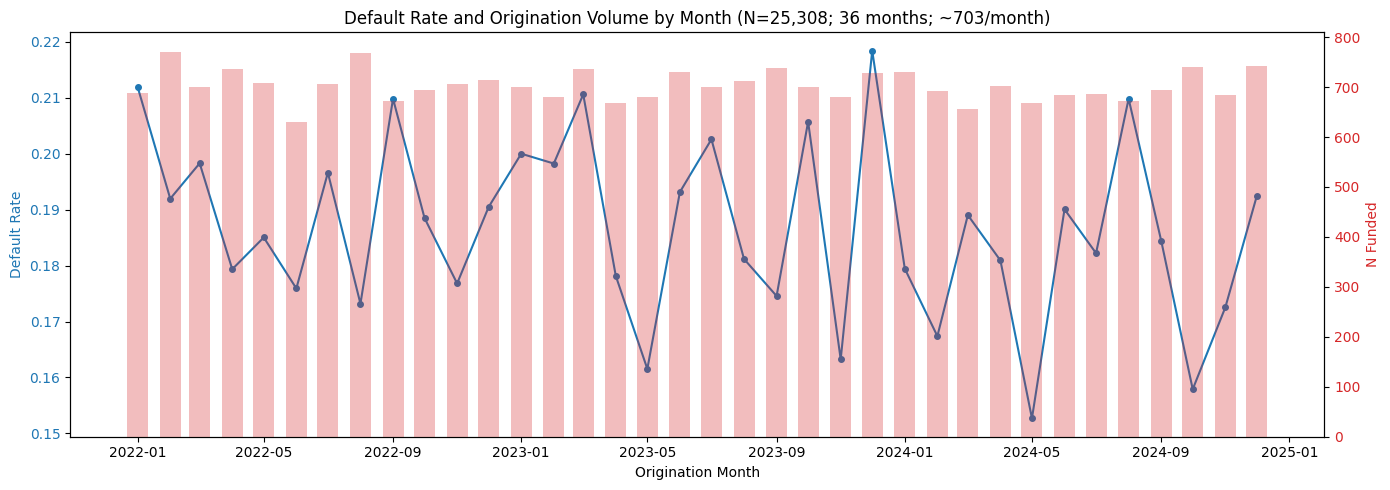

In [10]:
cls_eda.plot_target_by_month()

## Correlation with Target

In [11]:
cls_eda.correlation_with_target()
cls_eda.df_corr

,col,type,correlation,correlation_abs
24,state_ma,phi,-0.000157,0.000157
17,state_??,phi,-0.000367,0.000367
12,age,point_biserial,0.001162,0.001162
21,state_ga,phi,0.001306,0.001306
22,state_il,phi,0.001515,0.001515
14,channel_partner,phi,-0.001602,0.001602
26,state_mi,phi,-0.001645,0.001645
23,state_in,phi,0.002236,0.002236
2,employment_length_years,point_biserial,-0.002248,0.002248
36,state_wa,phi,-0.002807,0.002807


## Signed Correlation Bar Chart

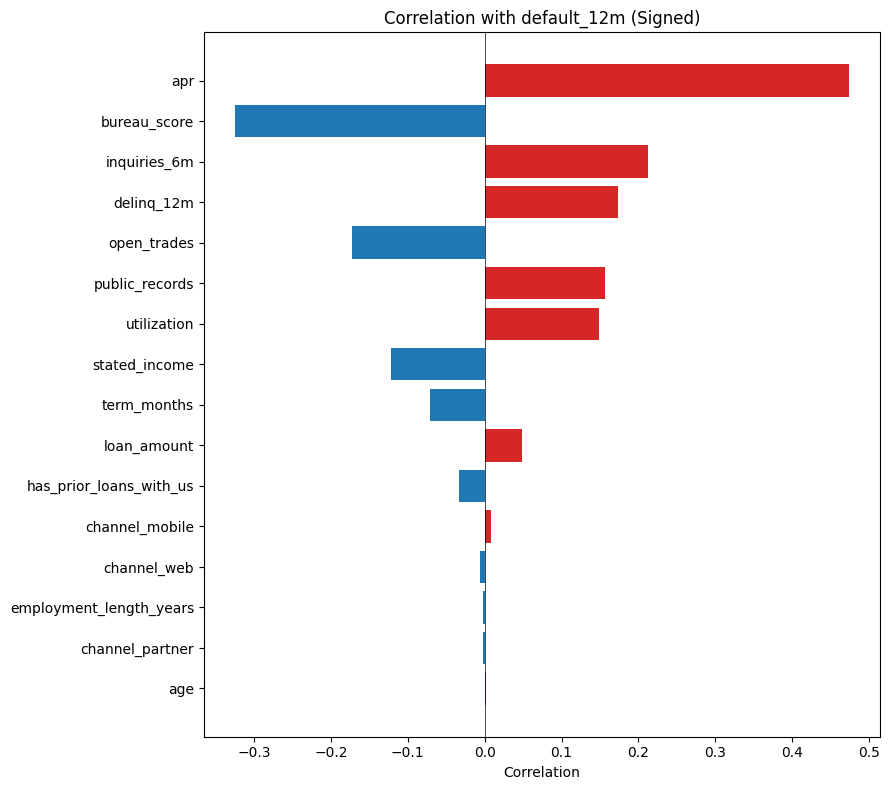

In [12]:
cls_eda.plot_correlation_with_target()

## Feature Correlation Heatmap

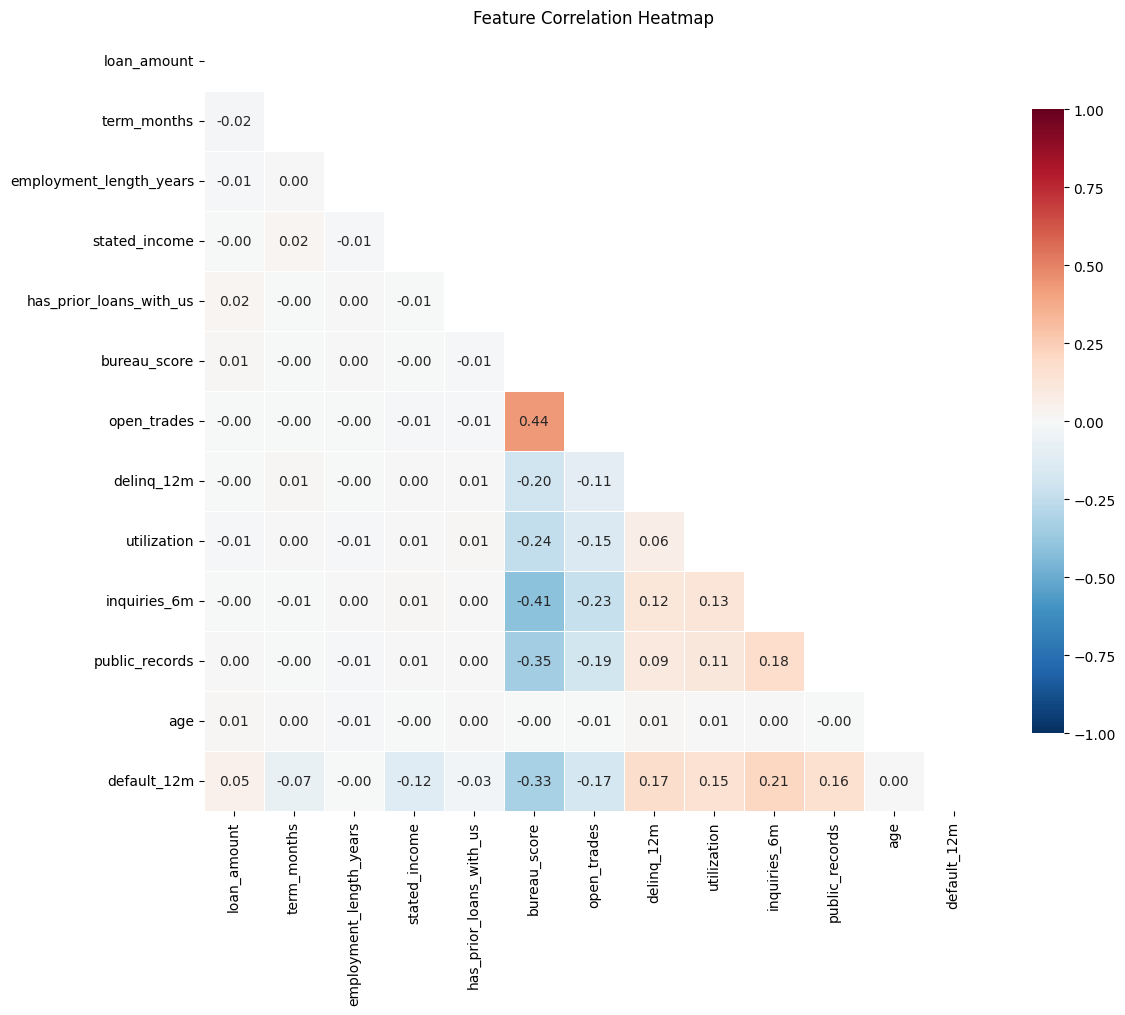

In [13]:
cls_eda.plot_correlation_heatmap()

## Violin Plots (Distributions and Outliers)

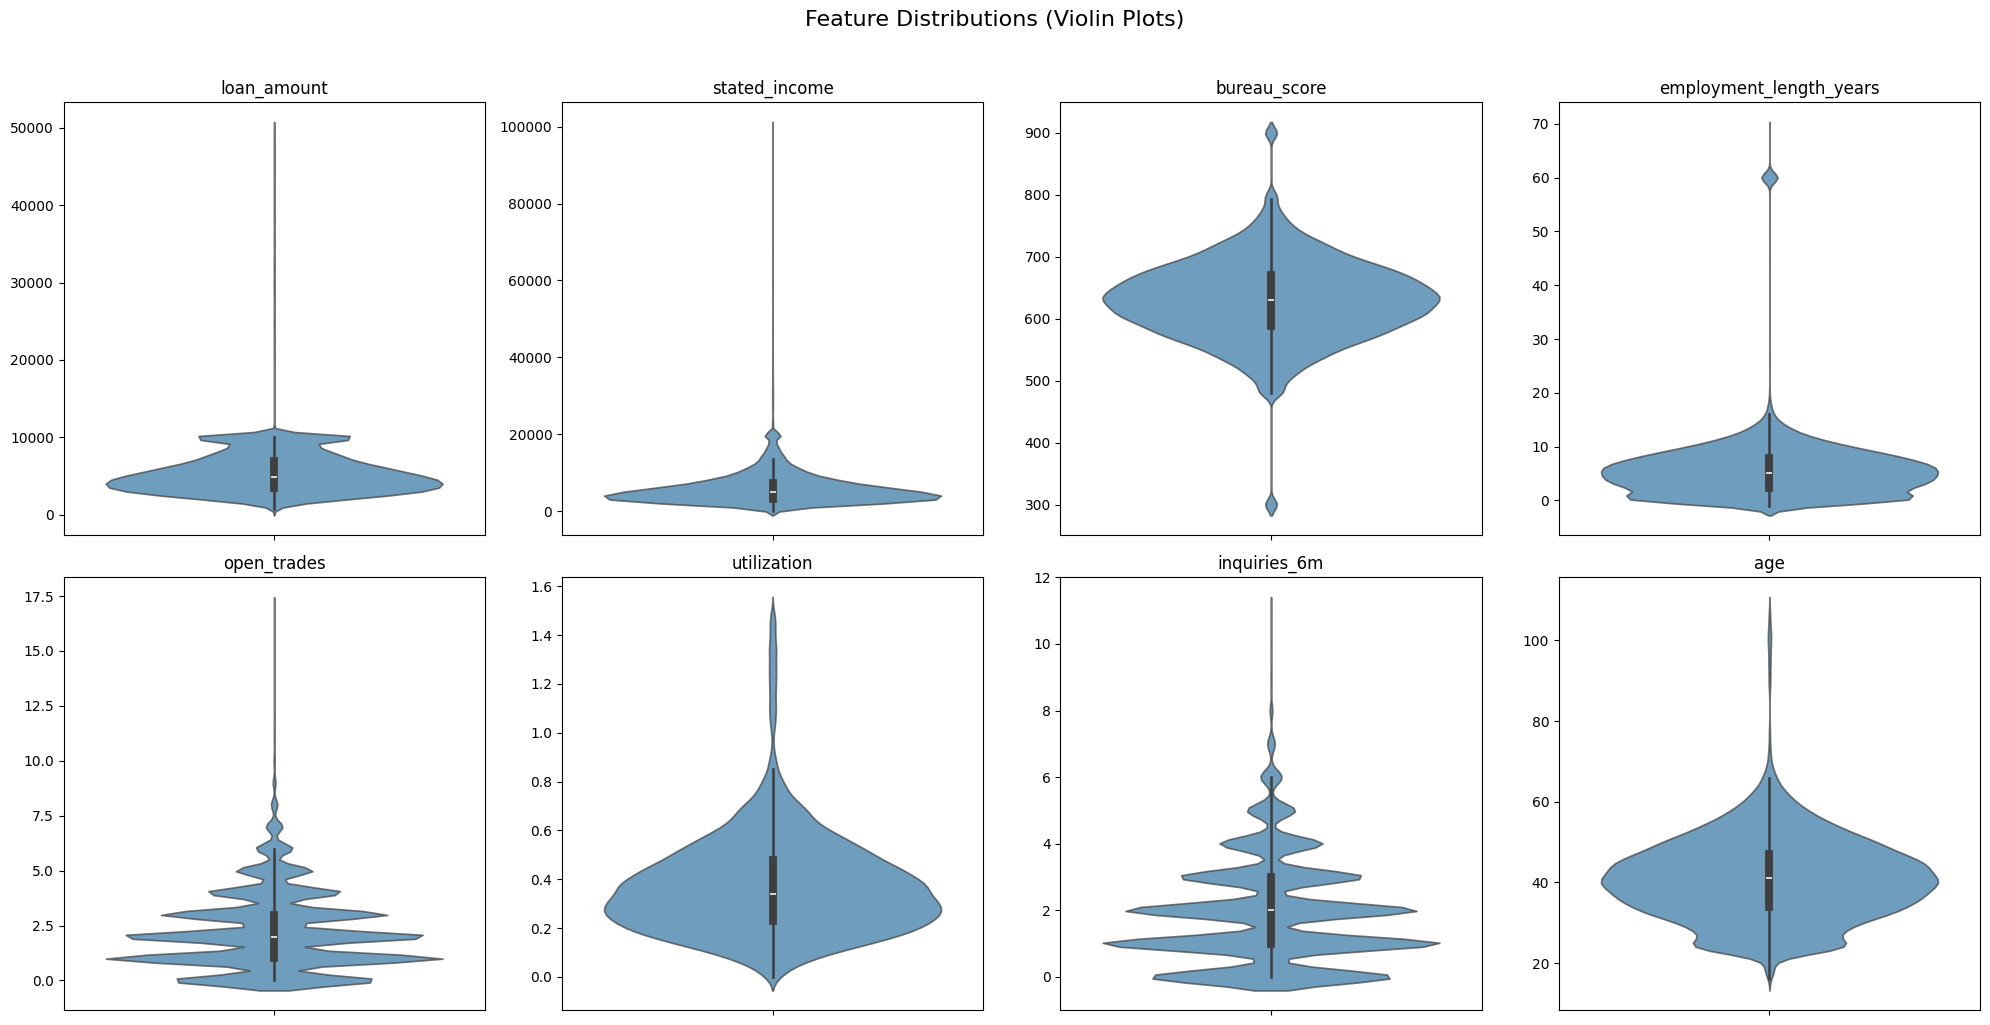

In [14]:
cls_eda.make_violin_plots()

## Lift Plots (Univariate Risk Trends)

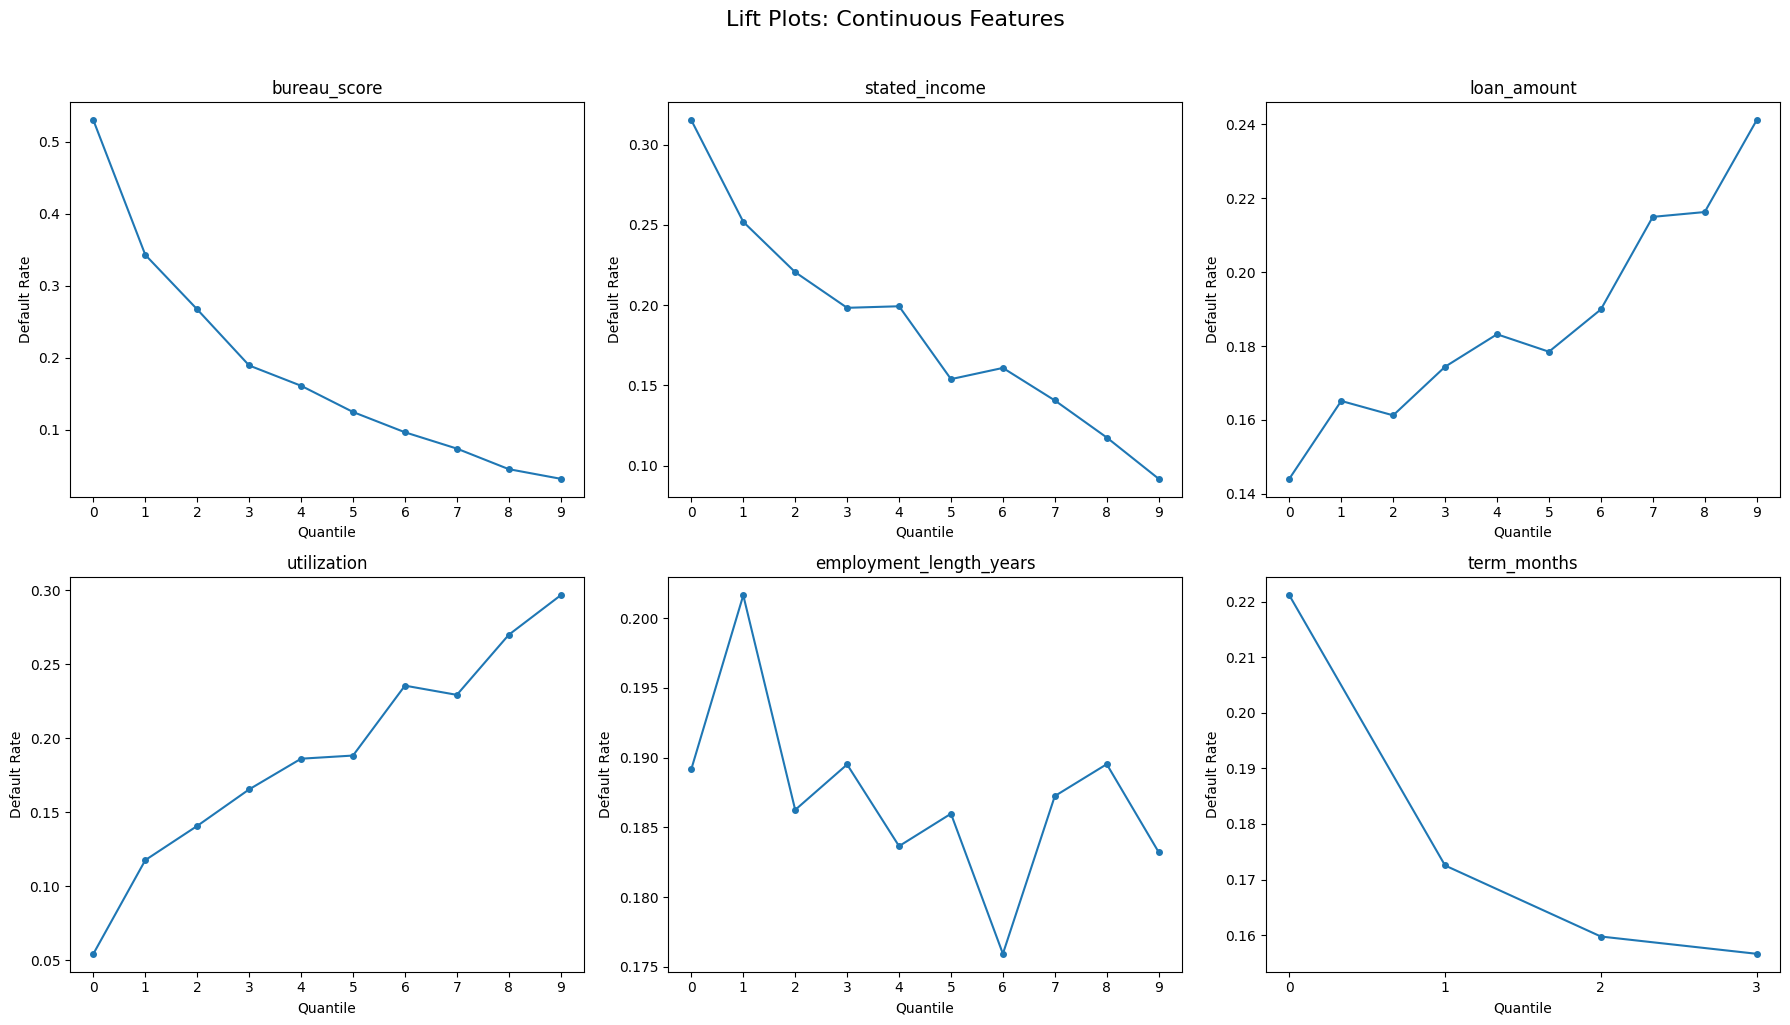

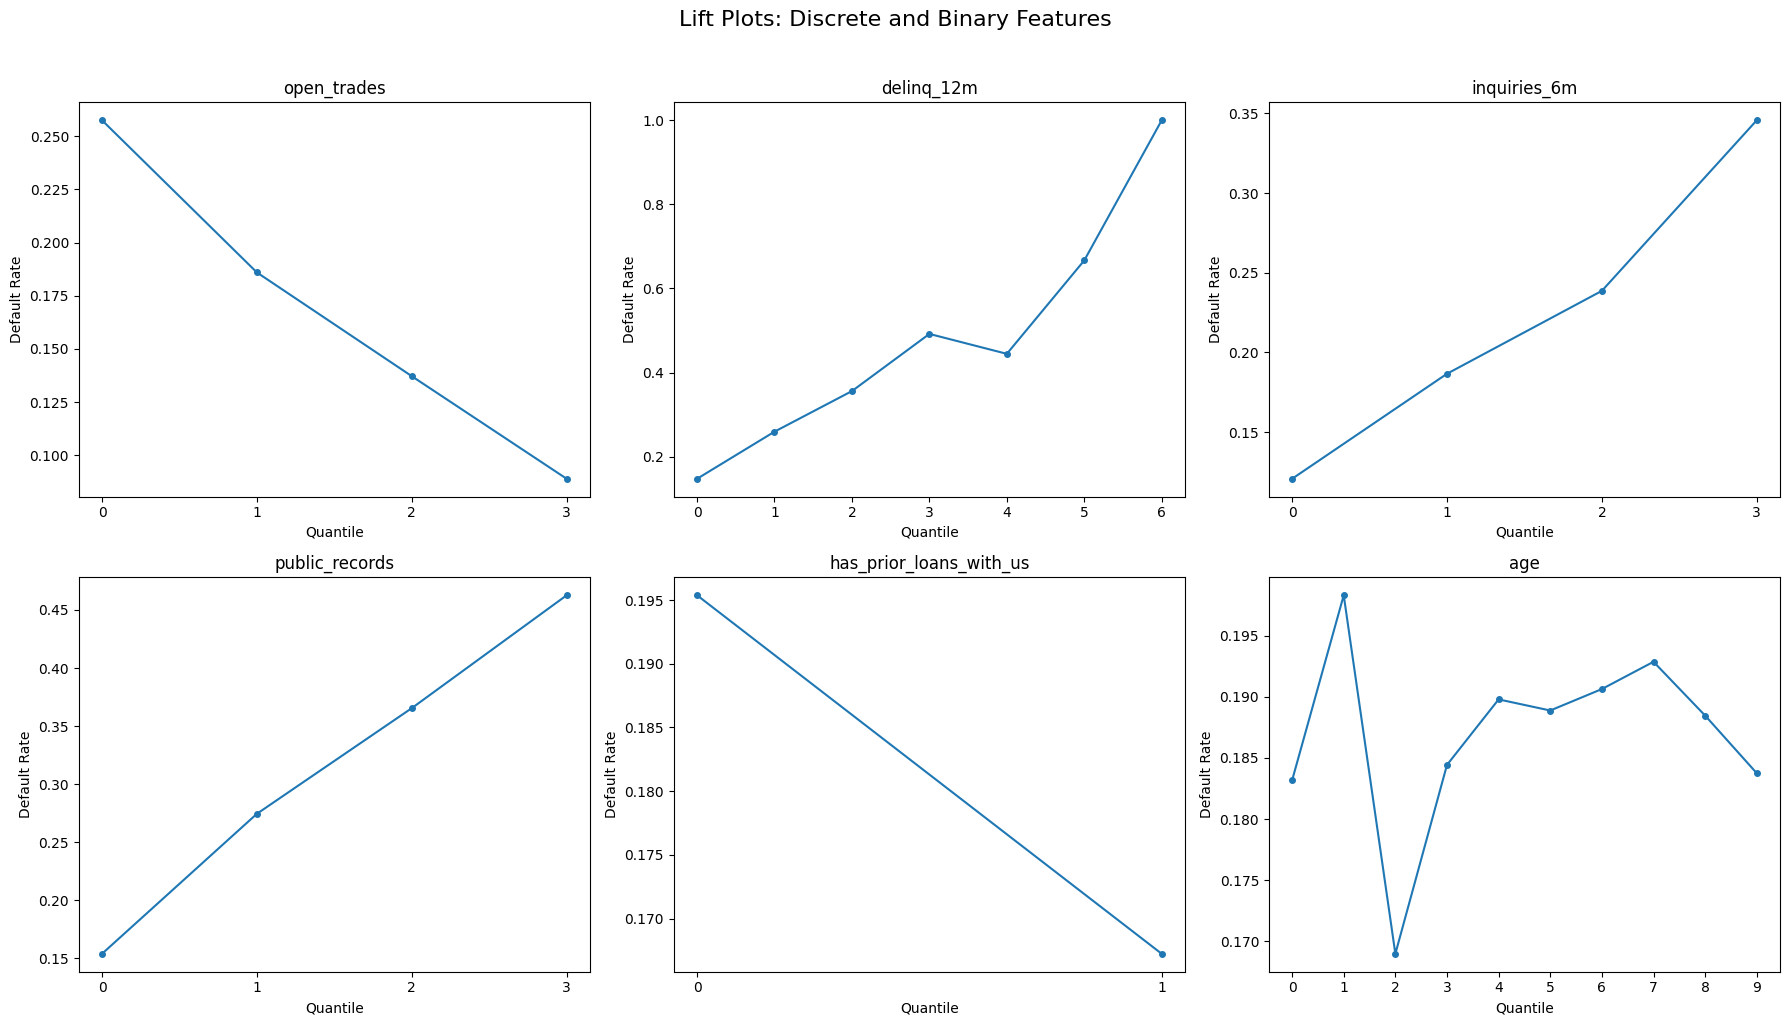

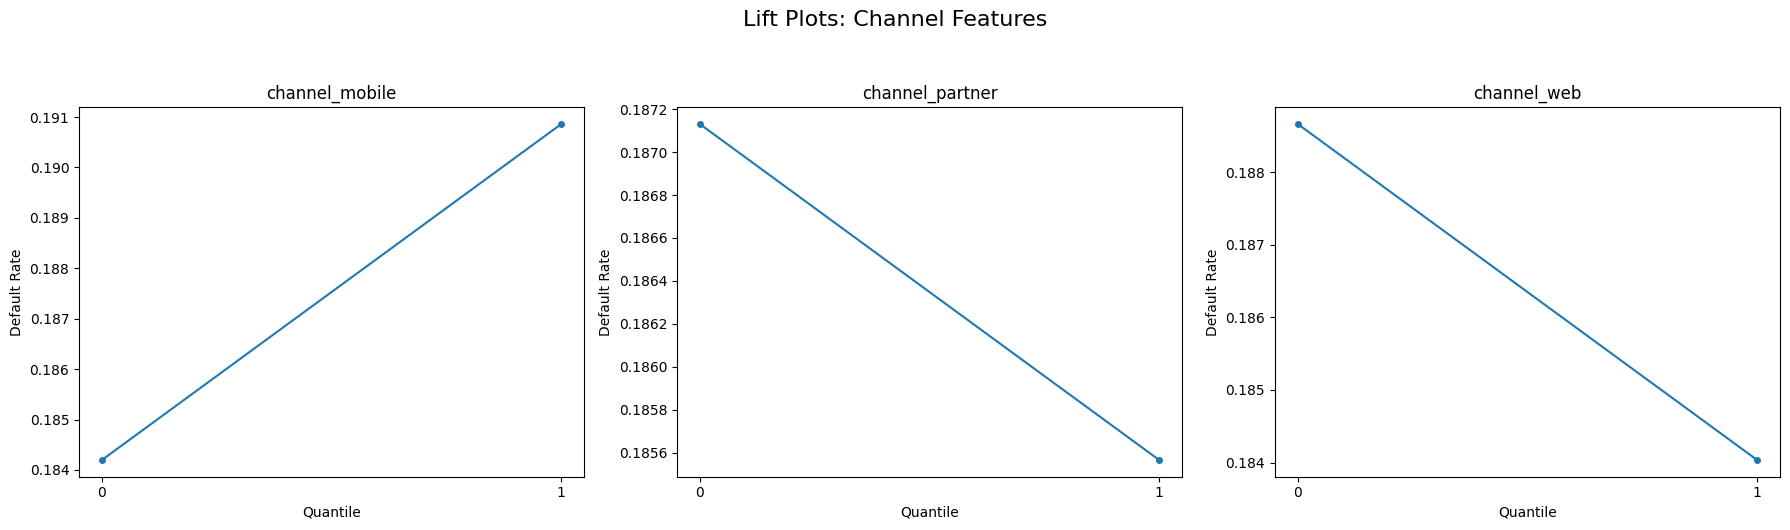

In [15]:
cls_eda.make_lift_plots()